First 10 rows:
   Day  Ad_Spend  Ad_Spend_Lag1  is_weekend  Users
0    1      22.8            0.0           0    158
1    2      16.1           22.8           0    181
2    3      56.2           16.1           0    288
3    4      47.0           56.2           0    355
4    5      41.9           47.0           0    317
5    6       0.0           41.9           1    215
6    7      53.5            0.0           1    311
7    8      54.7           53.5           0    327
8    9      44.2           54.7           0    338
9   10       0.0           44.2           0    160

Last 10 rows:
     Day  Ad_Spend  Ad_Spend_Lag1  is_weekend  Users
170  171      15.9           15.6           0    224
171  172      55.2           15.9           0    331
172  173      44.8           55.2           0    393
173  174      54.6           44.8           1    410
174  175       0.0           54.6           1    267
175  176       0.0            0.0           0    137
176  177      22.7            0.0     

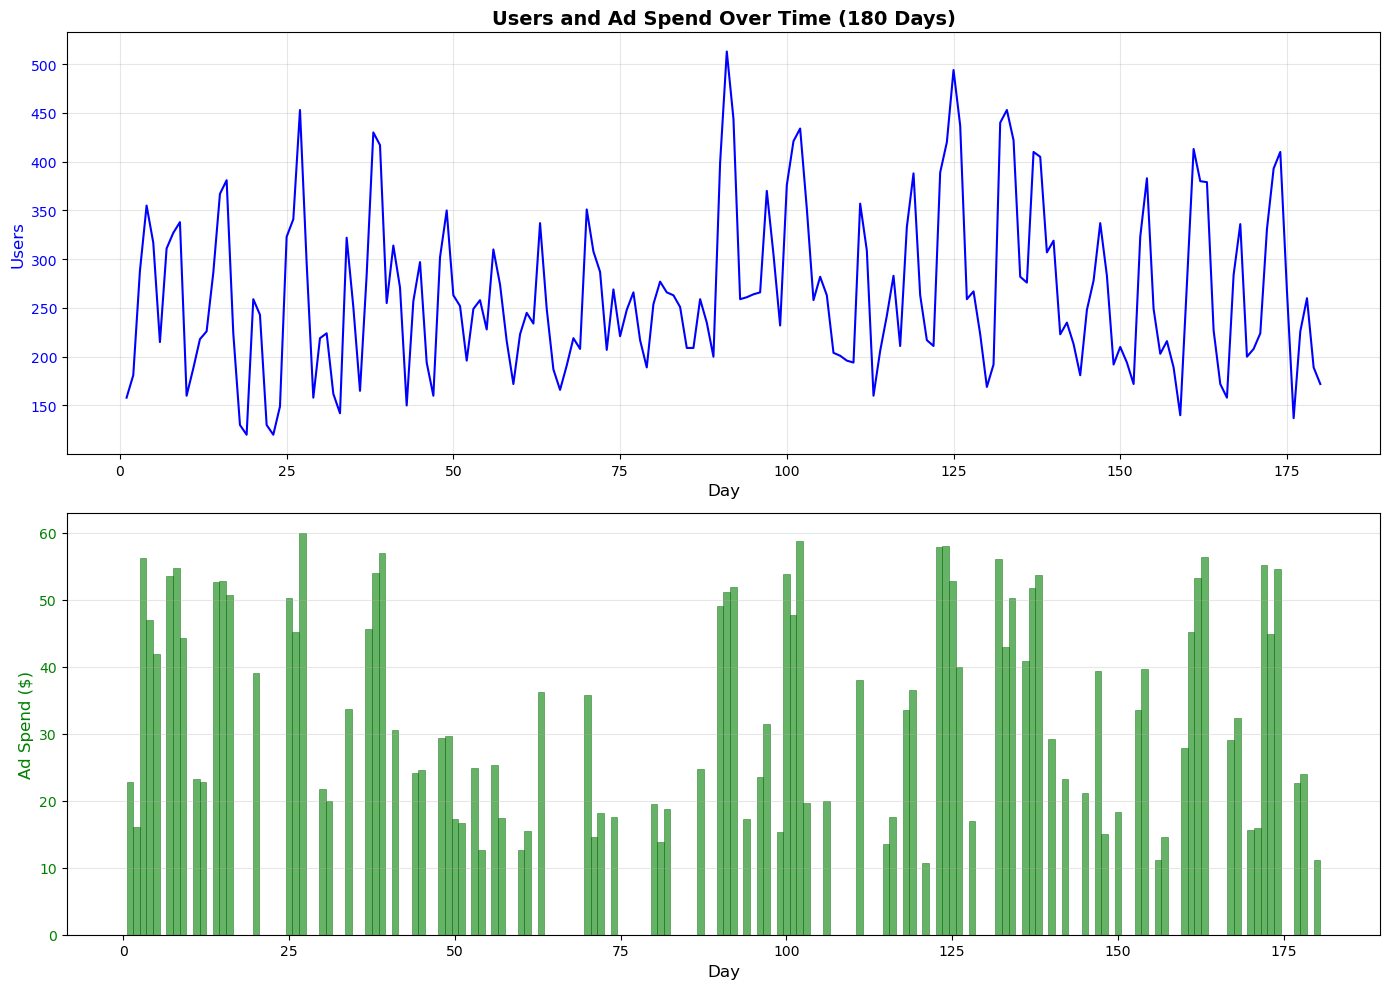

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_days = 180
min_zero_days = 82

# Initialize arrays
days = np.arange(1, n_days + 1)
ad_spend = np.zeros(n_days)

# Determine weekends
# Assumption: Day 1 is Saturday, so Thursday = day % 7 == 6 and Friday = day % 7 == 0
is_weekend = np.array([1 if (d % 7 in [6, 0]) else 0 for d in days])
weekend_indices = np.where(is_weekend == 1)[0]

# Protect some weekends from being zero-spend days
protected_weekend_count = int(len(weekend_indices) * 0.4)  # Protect 40% of weekends
protected_weekends = set(np.random.choice(weekend_indices, protected_weekend_count, replace=False))

# Select zero-spend days
available_for_zero = [i for i in range(n_days) if i not in protected_weekends]
zero_days = set(np.random.choice(available_for_zero, min_zero_days, replace=False))

# Remaining days for campaigns and regular spend
remaining_days = [i for i in range(n_days) if i not in zero_days]

# Create 3-day campaigns (up to 12 campaigns)
max_campaigns = 12
campaign_day_set = set()
campaigns_created = 0

for _ in range(max_campaigns):
    # Find valid start days (not in zero_days, not already in a campaign, and has 2 consecutive days available)
    valid_starts = [
        i for i in remaining_days
        if i not in campaign_day_set
        and i + 1 not in zero_days and i + 1 not in campaign_day_set
        and i + 2 not in zero_days and i + 2 not in campaign_day_set
        and i + 1 < n_days and i + 2 < n_days
    ]
    
    if not valid_starts:
        break
    
    start_day = np.random.choice(valid_starts)
    campaign_days = [start_day, start_day + 1, start_day + 2]
    
    # Assign high spend to campaign days
    for day in campaign_days:
        ad_spend[day] = np.random.uniform(40, 60)
        campaign_day_set.add(day)
    
    campaigns_created += 1

# Warning if fewer campaigns were created
if campaigns_created < max_campaigns:
    print(f"⚠️  Warning: Only {campaigns_created} campaigns created (target was {max_campaigns})")

# Assign spend to remaining non-zero, non-campaign days
for i in remaining_days:
    if ad_spend[i] == 0:  # Not assigned in campaigns
        if is_weekend[i] == 1:
            ad_spend[i] = np.random.uniform(25, 40)  # Higher spend on weekends
        else:
            ad_spend[i] = np.random.uniform(10, 25)  # Regular spend on weekdays

# Create lagged ad spend
ad_spend_lag1 = np.roll(ad_spend, 1)
ad_spend_lag1[0] = 0

# Calculate base users
beta_0 = 100
beta_1 = 3
beta_2 = 1.5
beta_3 = 2
beta_4 = -0.01
beta_5 = 50

users_base = (
    beta_0
    + beta_1 * ad_spend
    + beta_2 * ad_spend_lag1
    + beta_3 * days
    + beta_4 * (days ** 2)
    + beta_5 * is_weekend
)

# Generate users using Poisson distribution
users = np.random.poisson(np.maximum(users_base, 1))
ad_spend = np.round(ad_spend, 1)
ad_spend_lag1 = np.round(ad_spend_lag1, 1)

# Create DataFrame
df = pd.DataFrame({
    "Day": days,
    "Ad_Spend": ad_spend,
    "Ad_Spend_Lag1": ad_spend_lag1,
    "is_weekend": is_weekend,
    "Users": users
})


# Save to CSV
df.to_csv("app_users_dataset.csv", index=False)

# Display first and last 10 rows
print("=" * 60)
print("First 10 rows:")
print(df.head(10))
print("\n" + "=" * 60)
print("Last 10 rows:")
print(df.tail(10))

# Descriptive statistics
print("\n" + "=" * 60)
print("Descriptive Statistics:")
print(df.describe())

# Ad_Spend distribution statistics
print("\n" + "=" * 60)
print("Ad_Spend Distribution:")
print(f"  Zero-spend days: {np.sum(ad_spend == 0)} days")
print(f"  Campaign days: {len(campaign_day_set)} days ({campaigns_created} campaigns)")
print(f"  Weekend non-zero days: {np.sum((is_weekend == 1) & (ad_spend > 0))} days")
print(f"  Regular non-zero days: {np.sum((is_weekend == 0) & (ad_spend > 0) & (ad_spend < 40))} days")
print(f"\nAverage Ad_Spend:")
print(f"  Campaign days: ${ad_spend[list(campaign_day_set)].mean():.2f}" if campaign_day_set else "  Campaign days: N/A")
print(f"  Weekend days (non-campaign): ${ad_spend[(is_weekend == 1) & (ad_spend > 0) & (ad_spend < 40)].mean():.2f}")
print(f"  Regular days (non-campaign): ${ad_spend[(is_weekend == 0) & (ad_spend > 0) & (ad_spend < 40)].mean():.2f}")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Users over time
ax1.plot(df["Day"], df["Users"], color="blue", linewidth=1.5)
ax1.set_xlabel("Day", fontsize=12)
ax1.set_ylabel("Users", fontsize=12, color="blue")
ax1.set_title("Users and Ad Spend Over Time (180 Days)", fontsize=14, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(True, alpha=0.3)

# Ad_Spend over time (bar chart)
ax2.bar(df["Day"], df["Ad_Spend"], color="green", alpha=0.6, width=1, edgecolor="darkgreen", linewidth=0.5)
ax2.set_xlabel("Day", fontsize=12)
ax2.set_ylabel("Ad Spend ($)", fontsize=12, color="green")
ax2.tick_params(axis="y", labelcolor="green")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("./images/users_and_adspend_over_time.png", dpi=300, bbox_inches="tight")
print("\n" + "=" * 60)
print("✅ Plot saved as 'users_and_adspend_over_time.png'")
print("✅ Dataset saved as 'app_users_dataset.csv'")
